# FSNet Winner Region Sweep

This notebook evaluates one FSNet ensemble on the full `2000`-instance test set, sweeps multiple 1D and 2D metrics, and shows the best separating views for member winners.


In [1]:
import glob
import itertools
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

from utils.evaluator import Evaluator
from utils.trainer import DEVICE, create_model, load_instance


## Config

In [2]:
RUN_DIR = 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre'
OUT_PNG_1D = 'results/fsnet_seed0_best_1d_metric.png'
OUT_PNG_2D = 'results/fsnet_seed0_best_2d_metric.png'
SUBSET_N = 2000
BATCH_SIZE = 128
MERIT_EQ_WEIGHT = 1e5
MERIT_INEQ_WEIGHT = 1e5
MIN_WINS_TO_PLOT = 10

print('run_dir:', RUN_DIR)
print('subset_n:', SUBSET_N)
print('out_png_1d:', OUT_PNG_1D)
print('out_png_2d:', OUT_PNG_2D)
print('device:', DEVICE)


run_dir: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre
subset_n: 2000
out_png_1d: results/fsnet_seed0_best_1d_metric.png
out_png_2d: results/fsnet_seed0_best_2d_metric.png
device: cpu


## Helpers

In [3]:
def resolve_checkpoints(run_dir):
    pattern = os.path.join(run_dir, 'members', 'member_[0-9]*.pt')
    member_files = sorted(
        [
            f for f in glob.glob(pattern)
            if os.path.basename(f).startswith('member_') and '_epoch_' not in os.path.basename(f)
        ]
    )
    if member_files:
        return member_files
    model_pt = os.path.join(run_dir, 'model.pt')
    if os.path.isfile(model_pt):
        return [model_pt]
    raise FileNotFoundError(f'No model.pt or members/member_*.pt found in {run_dir}')


def load_single_model(ckpt_path, opt_problem):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    config = ckpt['config']
    model = create_model(opt_problem, config['method'], config)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, config


def evaluate_member(model, evaluator, dataset, batch_size=128):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    out = {k: [] for k in ['raw_merit', 'final_merit', 'repair_gain', 'move_l2']}

    for x_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        with torch.no_grad():
            y_raw = evaluator.opt_problem.scale(model(x_batch))
            y_final = evaluator._post_process_predictions(x_batch, y_raw)

            raw_merit = (
                evaluator.opt_problem.obj_fn(y_raw)
                + MERIT_EQ_WEIGHT * evaluator.opt_problem.eq_resid(x_batch, y_raw).abs().sum(dim=1)
                + MERIT_INEQ_WEIGHT * evaluator.opt_problem.ineq_resid(x_batch, y_raw).abs().sum(dim=1)
            )
            final_merit = (
                evaluator.opt_problem.obj_fn(y_final)
                + MERIT_EQ_WEIGHT * evaluator.opt_problem.eq_resid(x_batch, y_final).abs().sum(dim=1)
                + MERIT_INEQ_WEIGHT * evaluator.opt_problem.ineq_resid(x_batch, y_final).abs().sum(dim=1)
            )
            move_l2 = torch.linalg.norm(y_final - y_raw, dim=1)
            repair_gain = raw_merit - final_merit

        for k, v in {
            'raw_merit': raw_merit,
            'final_merit': final_merit,
            'repair_gain': repair_gain,
            'move_l2': move_l2,
        }.items():
            out[k].append(v.detach().cpu().numpy())

    return {k: np.concatenate(v) for k, v in out.items()}


def score_qda(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.3, random_state=0, stratify=labels
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=ConvergenceWarning)
        warnings.simplefilter('ignore', category=UserWarning)
        clf = QuadraticDiscriminantAnalysis(reg_param=1e-3)
        clf.fit(x_train, y_train)
        pred = clf.predict(x_test)
    return balanced_accuracy_score(y_test, pred)


def print_table(headers, rows, floatfmt='{:.4f}', max_rows=None):
    rows = list(rows)
    if max_rows is not None:
        rows = rows[:max_rows]
    formatted = []
    for row in rows:
        cur = []
        for val in row:
            if isinstance(val, (float, np.floating)):
                cur.append(floatfmt.format(float(val)))
            else:
                cur.append(str(val))
        formatted.append(cur)
    widths = [len(str(h)) for h in headers]
    for row in formatted:
        for i, val in enumerate(row):
            widths[i] = max(widths[i], len(val))
    print(' | '.join(str(h).ljust(widths[i]) for i, h in enumerate(headers)))
    print('-+-'.join('-' * widths[i] for i in range(len(headers))))
    for row in formatted:
        print(' | '.join(row[i].ljust(widths[i]) for i in range(len(headers))))


## Evaluate Members On Test Instances

In [4]:
ckpts = resolve_checkpoints(RUN_DIR)
first = torch.load(ckpts[0], map_location='cpu', weights_only=False)
cfg = dict(first['config'])
cfg['ensemble_post'] = 'post'
cfg['ensemble_agg'] = 'best_merit'
cfg['_eval_only'] = True

problem, _ = load_instance(cfg)
evaluator = Evaluator(problem, 'FSNet', cfg)
x_test, y_test = problem.test_dataset.tensors
if SUBSET_N > len(x_test):
    raise RuntimeError(f'SUBSET_N={SUBSET_N} exceeds test set size {len(x_test)}')
subset = TensorDataset(x_test[:SUBSET_N], y_test[:SUBSET_N])

member_out = []
for i, ckpt in enumerate(ckpts):
    print(f'evaluating member {i}...')
    model, _ = load_single_model(ckpt, problem)
    member_out.append(evaluate_member(model, evaluator, subset, batch_size=BATCH_SIZE))

arrays = {k: np.stack([m[k] for m in member_out], axis=0) for k in member_out[0].keys()}
n_members, n_points = arrays['final_merit'].shape
winner = arrays['final_merit'].argmin(axis=0)
raw_winner = arrays['raw_merit'].argmin(axis=0)
idx = np.arange(n_points)

winner_counts = np.bincount(winner, minlength=n_members)
active_members = np.where(winner_counts >= MIN_WINS_TO_PLOT)[0]
plot_mask = np.isin(winner, active_members)

raw_sorted = np.sort(arrays['raw_merit'], axis=0)
final_sorted = np.sort(arrays['final_merit'], axis=0)
raw_order = np.argsort(arrays['raw_merit'], axis=0)
final_order = np.argsort(arrays['final_merit'], axis=0)

winner_move = arrays['move_l2'][winner, idx]
winner_repair_gain = arrays['repair_gain'][winner, idx]
winner_raw_merit = arrays['raw_merit'][winner, idx]
winner_final_merit = arrays['final_merit'][winner, idx]
raw_best_final_merit = arrays['final_merit'][raw_winner, idx]
raw_best_move = arrays['move_l2'][raw_winner, idx]
raw_best_repair_gain = arrays['repair_gain'][raw_winner, idx]

pairwise_raw = []
pairwise_final = []
pairwise_move = []
for i in range(n_members):
    for j in range(i + 1, n_members):
        pairwise_raw.append(np.abs(arrays['raw_merit'][i] - arrays['raw_merit'][j]))
        pairwise_final.append(np.abs(arrays['final_merit'][i] - arrays['final_merit'][j]))
        pairwise_move.append(np.abs(arrays['move_l2'][i] - arrays['move_l2'][j]))

pairwise_raw = np.stack(pairwise_raw, axis=0)
pairwise_final = np.stack(pairwise_final, axis=0)
pairwise_move = np.stack(pairwise_move, axis=0)


evaluating member 0...
evaluating member 1...
evaluating member 2...
evaluating member 3...
evaluating member 4...


In [5]:
metrics = {
    'winner_move_l2': winner_move,
    # 'winner_repair_gain': winner_repair_gain,
    # 'winner_raw_merit': winner_raw_merit,
    'winner_final_merit': winner_final_merit,
    'best_raw_merit': raw_sorted[0],
    'best_final_merit': final_sorted[0],
    'raw_margin_top1_top2': raw_sorted[1] - raw_sorted[0],
    'final_margin_top1_top2': final_sorted[1] - final_sorted[0],
    'raw_margin_top1_mean_rest': arrays['raw_merit'].mean(axis=0) - raw_sorted[0],
    'final_margin_top1_mean_rest': arrays['final_merit'].mean(axis=0) - final_sorted[0],
    'raw_disagree_std': arrays['raw_merit'].std(axis=0),
    'final_disagree_std': arrays['final_merit'].std(axis=0),
    'raw_disagree_range': arrays['raw_merit'].max(axis=0) - arrays['raw_merit'].min(axis=0),
    'final_disagree_range': arrays['final_merit'].max(axis=0) - arrays['final_merit'].min(axis=0),
    'move_mean': arrays['move_l2'].mean(axis=0),
    'move_std': arrays['move_l2'].std(axis=0),
    'move_range': arrays['move_l2'].max(axis=0) - arrays['move_l2'].min(axis=0),
    # 'repair_gain_mean': arrays['repair_gain'].mean(axis=0),
    'repair_gain_std': arrays['repair_gain'].std(axis=0),
    'repair_gain_range': arrays['repair_gain'].max(axis=0) - arrays['repair_gain'].min(axis=0),
    'raw_best_to_final_winner_gap': raw_best_final_merit - winner_final_merit,
    'raw_best_move_l2': raw_best_move,
    'raw_best_repair_gain': raw_best_repair_gain,
    # 'winner_rank_shift': (raw_order == winner).argmax(axis=0).astype(float),
    # 'raw_winner_is_final_winner': (raw_winner == winner).astype(float),
    'pairwise_raw_mean': pairwise_raw.mean(axis=0),
    'pairwise_raw_range': pairwise_raw.max(axis=0) - pairwise_raw.min(axis=0),
    'pairwise_final_mean': pairwise_final.mean(axis=0),
    'pairwise_final_range': pairwise_final.max(axis=0) - pairwise_final.min(axis=0),
    'pairwise_move_mean': pairwise_move.mean(axis=0),
    'pairwise_move_range': pairwise_move.max(axis=0) - pairwise_move.min(axis=0),
}

metrics['final_vs_raw_disagree_ratio'] = metrics['final_disagree_std'] / (metrics['raw_disagree_std'] + 1e-9)
# metrics['winner_gain_over_raw_best'] = winner_repair_gain - raw_best_repair_gain
metrics['repair_sensitivity'] = metrics['move_std'] * metrics['repair_gain_std']
# metrics['winner_move_x_gain'] = winner_move * winner_repair_gain
# metrics['winner_gain_over_margin'] = winner_repair_gain / (metrics['raw_margin_top1_top2'] + 1e-9)
metrics['pairwise_final_over_raw'] = metrics['pairwise_final_mean'] / (metrics['pairwise_raw_mean'] + 1e-9)
metrics['repair_x_raw_disagree'] = metrics['repair_gain_std'] * metrics['raw_disagree_std']
metrics['move_x_final_disagree'] = metrics['move_std'] * metrics['final_disagree_std']

print('winner counts:', winner_counts.tolist())
print('active members:', active_members.tolist())
print('points kept:', int(plot_mask.sum()))
print('n_metrics:', len(metrics))
if len(active_members) < 2:
    raise RuntimeError('Fewer than 2 members meet MIN_WINS_TO_PLOT.')


winner counts: [970, 388, 8, 226, 408]
active members: [0, 1, 3, 4]
points kept: 1992
n_metrics: 31


## Sweep 1D And 2D Metrics

In [6]:
labels = winner[plot_mask]
feature_names = list(metrics.keys())

one_d_rows = []
best_1d = None
for f in feature_names:
    features_1d = np.column_stack([metrics[f][plot_mask]])
    try:
        score = score_qda(features_1d, labels)
    except Exception:
        continue
    one_d_rows.append((f, score))
    if best_1d is None or score > best_1d[0]:
        best_1d = (score, f)

two_d_rows = []
best_2d = None
for f1, f2 in itertools.combinations(feature_names, 2):
    features_2d = np.column_stack([metrics[f1][plot_mask], metrics[f2][plot_mask]])
    try:
        score = score_qda(features_2d, labels)
    except Exception:
        continue
    two_d_rows.append((f1, f2, score))
    if best_2d is None or score > best_2d[0]:
        best_2d = (score, f1, f2)

one_d_rows = sorted(one_d_rows, key=lambda x: x[1], reverse=True)
two_d_rows = sorted(two_d_rows, key=lambda x: x[2], reverse=True)

print('Top 1D metrics:')
print_table(['metric', 'balanced_accuracy'], one_d_rows, max_rows=10)
print('\nTop 2D metric pairs:')
print_table(['x_metric', 'y_metric', 'balanced_accuracy'], two_d_rows, max_rows=15)

if best_1d is None or best_2d is None:
    raise RuntimeError('Could not score enough metric combinations.')

BEST_1D_SCORE, BEST_1D_METRIC = best_1d
BEST_2D_SCORE, X_METRIC, Y_METRIC = best_2d
print('\nBest 1D metric:', BEST_1D_METRIC, round(float(BEST_1D_SCORE), 4))
print('Best 2D metric pair:', X_METRIC, Y_METRIC, round(float(BEST_2D_SCORE), 4))


Top 1D metrics:
metric                      | balanced_accuracy
----------------------------+------------------
winner_final_merit          | 0.3146           
best_final_merit            | 0.3146           
pairwise_final_range        | 0.2825           
final_disagree_std          | 0.2808           
final_disagree_range        | 0.2788           
pairwise_final_mean         | 0.2771           
final_margin_top1_mean_rest | 0.2754           
move_x_final_disagree       | 0.2649           
raw_margin_top1_mean_rest   | 0.2646           
winner_move_l2              | 0.2638           

Top 2D metric pairs:
x_metric           | y_metric                     | balanced_accuracy
-------------------+------------------------------+------------------
winner_final_merit | raw_best_to_final_winner_gap | 0.3239           
best_final_merit   | raw_best_to_final_winner_gap | 0.3239           
winner_final_merit | raw_disagree_range           | 0.3205           
winner_final_merit | repair_gain_ran

## Best 1D View

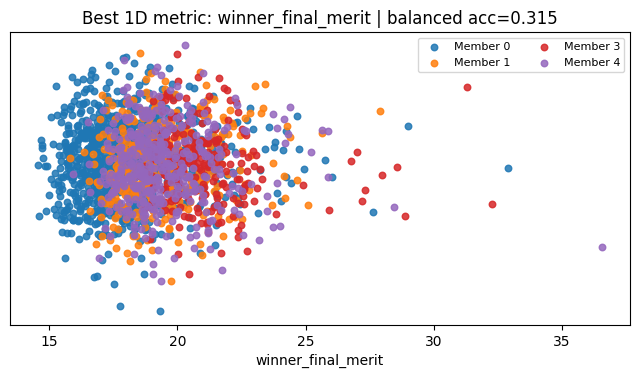

saved_plot: results/fsnet_seed0_best_1d_metric.png


In [7]:
x1 = metrics[BEST_1D_METRIC][plot_mask]
rng = np.random.default_rng(0)
y_jitter = rng.normal(0.0, 0.04, size=len(labels))

fig, ax = plt.subplots(figsize=(8, 3.8))
cmap = plt.get_cmap('tab10')
for m in active_members:
    mm = labels == m
    if not np.any(mm):
        continue
    ax.scatter(x1[mm], y_jitter[mm], s=22, alpha=0.85, color=cmap(m), label=f'Member {m}')

ax.set_xlabel(BEST_1D_METRIC)
ax.set_yticks([])
ax.set_title(f'Best 1D metric: {BEST_1D_METRIC} | balanced acc={BEST_1D_SCORE:.3f}')
ax.legend(fontsize=8, ncol=max(1, len(active_members) // 2))

os.makedirs(os.path.dirname(OUT_PNG_1D), exist_ok=True)
fig.savefig(OUT_PNG_1D, dpi=180, bbox_inches='tight')
plt.show()
print('saved_plot:', OUT_PNG_1D)


## Best 2D Winner Regions

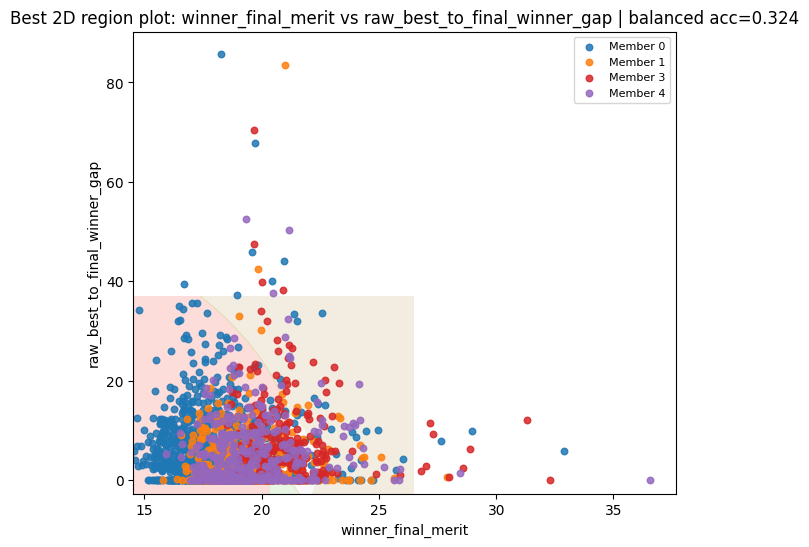

saved_plot: results/fsnet_seed0_best_2d_metric.png


In [8]:
x = metrics[X_METRIC][plot_mask]
y = metrics[Y_METRIC][plot_mask]
plot_xy = np.column_stack([x, y])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    warnings.simplefilter('ignore', category=UserWarning)
    clf = QuadraticDiscriminantAnalysis(reg_param=1e-3)
    clf.fit(plot_xy, labels)

x1_min, x1_max = np.quantile(x, [0.01, 0.99])
x2_min, x2_max = np.quantile(y, [0.01, 0.99])
pad1 = 0.08 * max(x1_max - x1_min, 1e-9)
pad2 = 0.08 * max(x2_max - x2_min, 1e-9)

gx, gy = np.meshgrid(
    np.linspace(x1_min - pad1, x1_max + pad1, 300),
    np.linspace(x2_min - pad2, x2_max + pad2, 300),
)
grid = np.column_stack([gx.ravel(), gy.ravel()])
gz = clf.predict(grid).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
levels = np.arange(gz.max() + 2) - 0.5
ax.contourf(gx, gy, gz, levels=levels, cmap='Pastel1', alpha=0.45)

cmap = plt.get_cmap('tab10')
for m in active_members:
    mm = labels == m
    if not np.any(mm):
        continue
    ax.scatter(x[mm], y[mm], s=22, alpha=0.85, color=cmap(m), label=f'Member {m}')

ax.set_title(f'Best 2D region plot: {X_METRIC} vs {Y_METRIC} | balanced acc={BEST_2D_SCORE:.3f}')
ax.set_xlabel(X_METRIC)
ax.set_ylabel(Y_METRIC)
ax.legend(fontsize=8)

os.makedirs(os.path.dirname(OUT_PNG_2D), exist_ok=True)
fig.savefig(OUT_PNG_2D, dpi=180, bbox_inches='tight')
plt.show()
print('saved_plot:', OUT_PNG_2D)
